In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)

In [2]:
import os
foldername = '/home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/time_series/'
os.makedirs(foldername, exist_ok=True)

In [23]:
import pandas as pd
import numpy as np

# ═══════════════════════════════════════════════════════════════════
#  FORECAST PARAMETERS — only change start_date to switch forecasts
# ═══════════════════════════════════════════════════════════════════
start_date = pd.Timestamp('2013-07-01')

month_str = start_date.strftime('%b').lower()
day_str   = start_date.strftime('%d')
year_str  = start_date.strftime('%Y')

noTAO_data_dir          = f'/data/SO3/averdy/TPOSE6/{month_str}{year_str}/diags_daily/'
noTAO_forecast_data_dir = f'/data/SO3/edavenport/tpose6/forecasts/{month_str}{day_str}{year_str}_tpose_noVel/'
vel_forecast_data_dir   = f'/data/SO3/edavenport/tpose6/forecasts/{month_str}{day_str}{year_str}/'

end_date        = start_date + pd.DateOffset(months=4) - pd.Timedelta(days=1)
n_forecast_days = (end_date - start_date).days
n_eval          = n_forecast_days

ref_date  = start_date.strftime('%Y-%m-%d')
itPerFile = 72
num_diags = n_forecast_days + 1
eval_slice = slice(0, n_forecast_days)

# TAO mooring locations
tao_lons      = np.array([190., 220., 250.])   # °E
tao_lon_labels = ['170°W', '140°W', '110°W']

eval_dates = pd.date_range(start_date, periods=n_eval)

print(f'Forecast: {start_date.date()} → {end_date.date()} ({n_forecast_days} days)')

Forecast: 2013-07-01 → 2013-10-31 (122 days)


### Load TPOSE

In [24]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
from xmitgcm import open_mdsdataset
plt.rcParams['font.size'] = 11

prefix   = ['diag_state']
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'
intervals = range(itPerFile, itPerFile * num_diags, itPerFile)

def open_tpose(data_dir):
    ds = open_mdsdataset(
        data_dir=data_dir, grid_dir=grid_dir,
        iters=intervals, prefix=prefix, ref_date=ref_date, delta_t=1200)
    for coord in ['XC', 'YC', 'Z', 'XG', 'YG']:
        ds[coord] = ds[coord].astype(float)
    return ds

ds_tpose_noTAO          = open_tpose(noTAO_data_dir)
ds_tpose_noTAO_forecast = open_tpose(noTAO_forecast_data_dir)
ds_tpose_vel_forecast   = open_tpose(vel_forecast_data_dir)

### Load GLORYS

In [25]:
glorys = xr.open_mfdataset('/data/SO3/edavenport/tpose6/glorys_data/glorys_*.nc', combine='by_coords')
glorys_wind = glorys[['uo', 'vo']].sel(
    time=slice(start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')),
    latitude=slice(-5, 5)
)

### Load TAO ADCP (daily average)

In [26]:
adcp = xr.open_dataset('/data/SO3/edavenport/tpose6/tao_profiles/TAO_WO_2013_ADCP.nc')

raw_dates = pd.to_datetime(
    adcp.prof_YYYYMMDD.values.astype(int).astype(str), format='%Y%m%d'
)
u_raw = adcp.prof_U.values.copy().astype(float)
v_raw = adcp.prof_V.values.copy().astype(float)
u_raw[u_raw == -9999.] = np.nan
v_raw[v_raw == -9999.] = np.nan

adcp_lons   = adcp.prof_lon.values
adcp_depths = adcp.prof_depth.values   # (62,) in metres

# Daily average: (time, location, depth)
tao_u = np.full((n_eval, len(tao_lons), len(adcp_depths)), np.nan)
tao_v = np.full((n_eval, len(tao_lons), len(adcp_depths)), np.nan)

for i, d in enumerate(eval_dates):
    for j, lon in enumerate(tao_lons):
        mask = (raw_dates == d) & (adcp_lons == lon)
        if mask.sum() > 0:
            tao_u[i, j, :] = np.nanmean(u_raw[mask, :], axis=0)
            tao_v[i, j, :] = np.nanmean(v_raw[mask, :], axis=0)

print(f'TAO shape: {tao_u.shape}  (time, location, depth)')

TAO shape: (122, 3, 62)  (time, location, depth)


/tmp/ipykernel_28073/480107646.py:22: RuntimeWarning: Mean of empty slice
  tao_u[i, j, :] = np.nanmean(u_raw[mask, :], axis=0)
/tmp/ipykernel_28073/480107646.py:23: RuntimeWarning: Mean of empty slice
  tao_v[i, j, :] = np.nanmean(v_raw[mask, :], axis=0)


### Interpolate TPOSE and GLORYS to TAO depths and locations

In [27]:
interp_depths     = adcp_depths          # positive downward (m)
neg_interp_depths = -interp_depths       # TPOSE Z convention

def extract_tpose_vel(ds):
    """Returns (u, v) each (time, location, depth)."""
    ds = ds.isel(time=eval_slice)
    loc_da   = xr.DataArray(tao_lons,          dims='location')
    depth_da = xr.DataArray(neg_interp_depths, dims='depth')

    u = (ds.UVEL
           .sel(YC=0.0, method='nearest')
           .interp(XG=loc_da, Z=depth_da, method='linear')
           .transpose('time', 'location', 'depth')
           .compute()).values

    v = (ds.VVEL
           .sel(YG=0.0, method='nearest')
           .interp(XC=loc_da, Z=depth_da, method='linear')
           .transpose('time', 'location', 'depth')
           .compute()).values

    return u, v

print('TPOSE-noVel state estimate...')
noTAO_u,     noTAO_v     = extract_tpose_vel(ds_tpose_noTAO)
print('TPOSE-noVel forecast...')
noTAO_fct_u, noTAO_fct_v = extract_tpose_vel(ds_tpose_noTAO_forecast)
print('TPOSE-Vel forecast...')
vel_fct_u,   vel_fct_v   = extract_tpose_vel(ds_tpose_vel_forecast)
print('Done.')

tao_lons_glorys = tao_lons - 360
loc_da_g   = xr.DataArray(tao_lons_glorys, dims='location')
depth_da_g = xr.DataArray(interp_depths,   dims='depth')

glorys_u = (glorys_wind.uo
              .sel(latitude=0.0, method='nearest')
              .interp(longitude=loc_da_g, depth=depth_da_g, method='linear')
              .transpose('time', 'location', 'depth')
              .isel(time=eval_slice)
              .compute()).values

glorys_v = (glorys_wind.vo
              .sel(latitude=0.0, method='nearest')
              .interp(longitude=loc_da_g, depth=depth_da_g, method='linear')
              .transpose('time', 'location', 'depth')
              .isel(time=eval_slice)
              .compute()).values

print('GLORYS extracted. Shape:', glorys_u.shape)

TPOSE-noVel state estimate...
TPOSE-noVel forecast...
TPOSE-Vel forecast...
Done.
GLORYS extracted. Shape: (122, 3, 62)


### Figures: depth–time Hovmöller at each mooring

One figure per mooring longitude (190°E, 220°E, 250°E).  
5 rows × 2 columns: rows = (1) TAO obs, (2) TPOSE-noVel state estimate,  
(3) TPOSE-noVel forecast, (4) TPOSE-Vel forecast, (5) GLORYS.  
Left column = U (zonal), right column = V (meridional).

/tmp/ipykernel_28073/1501294375.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


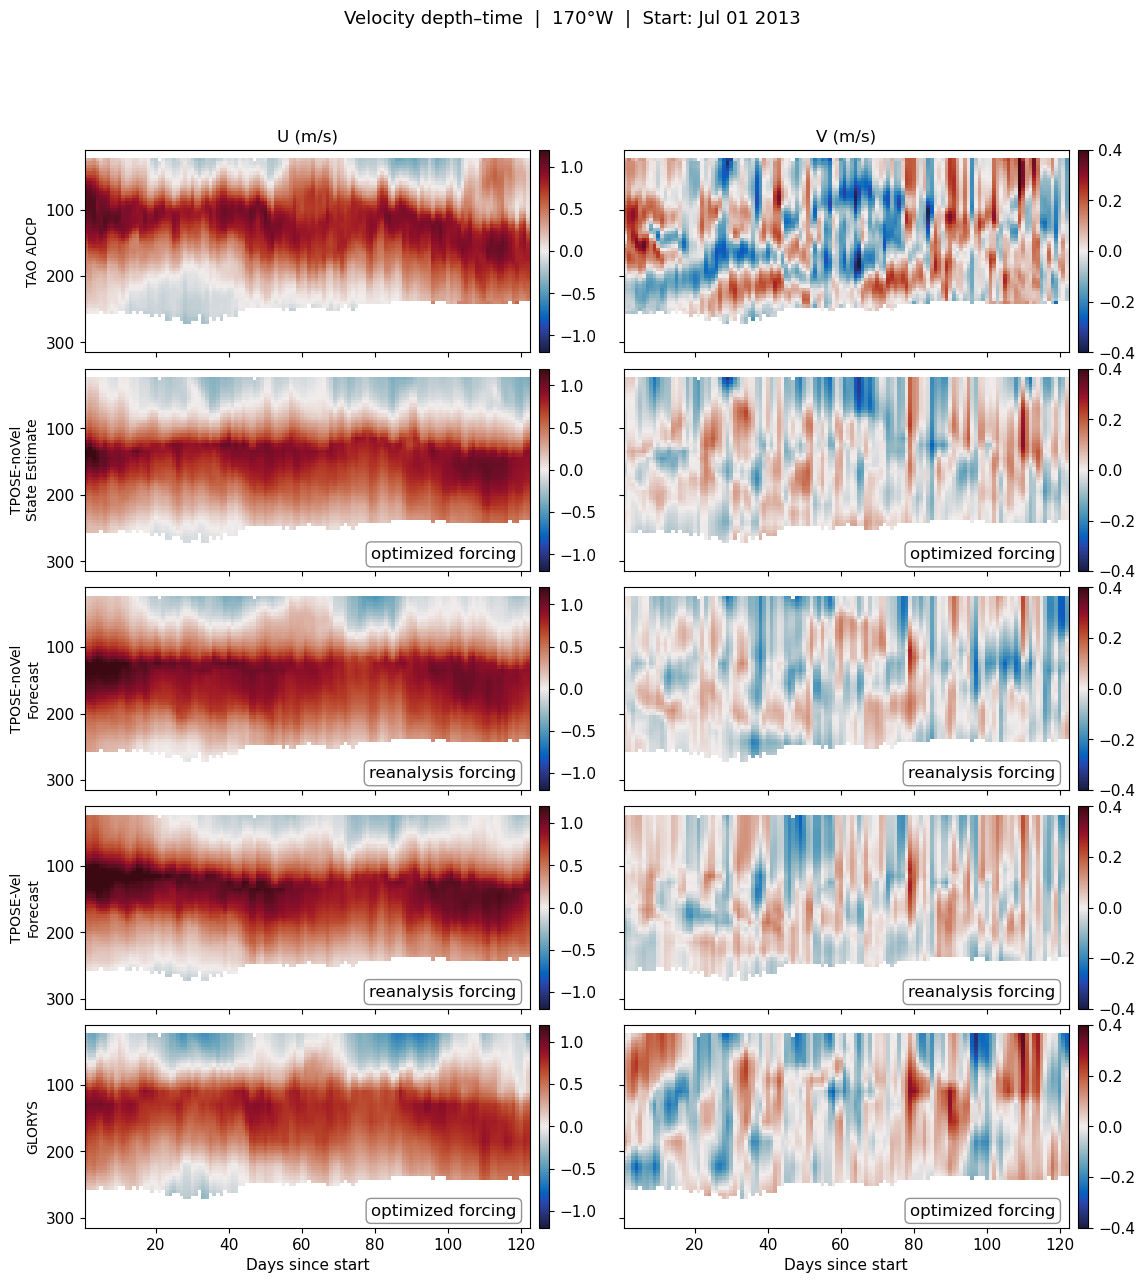

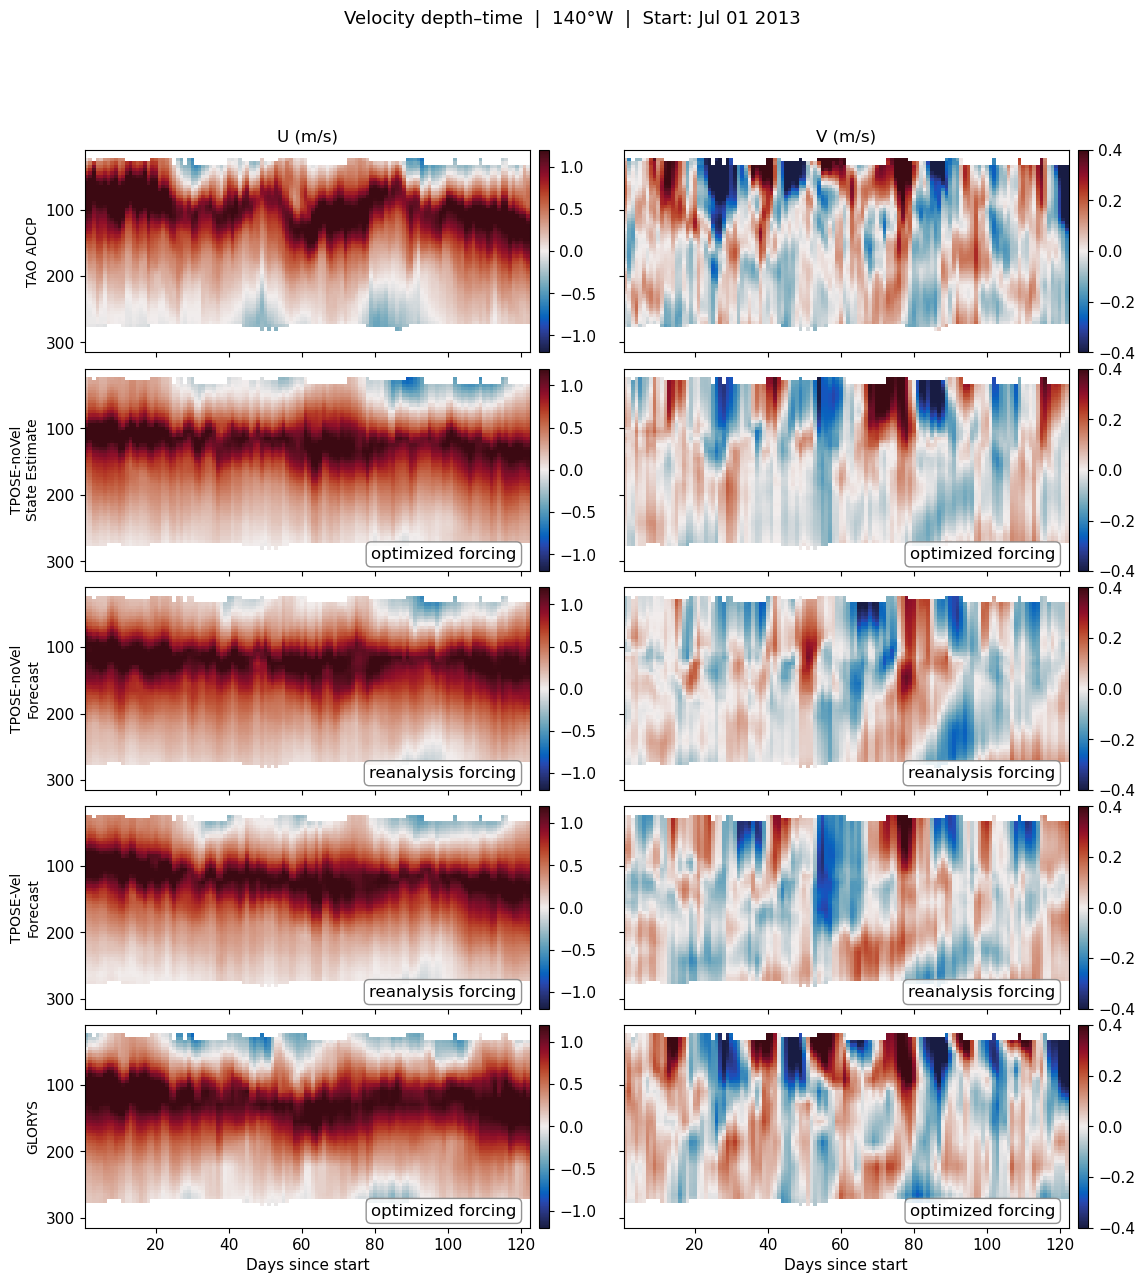

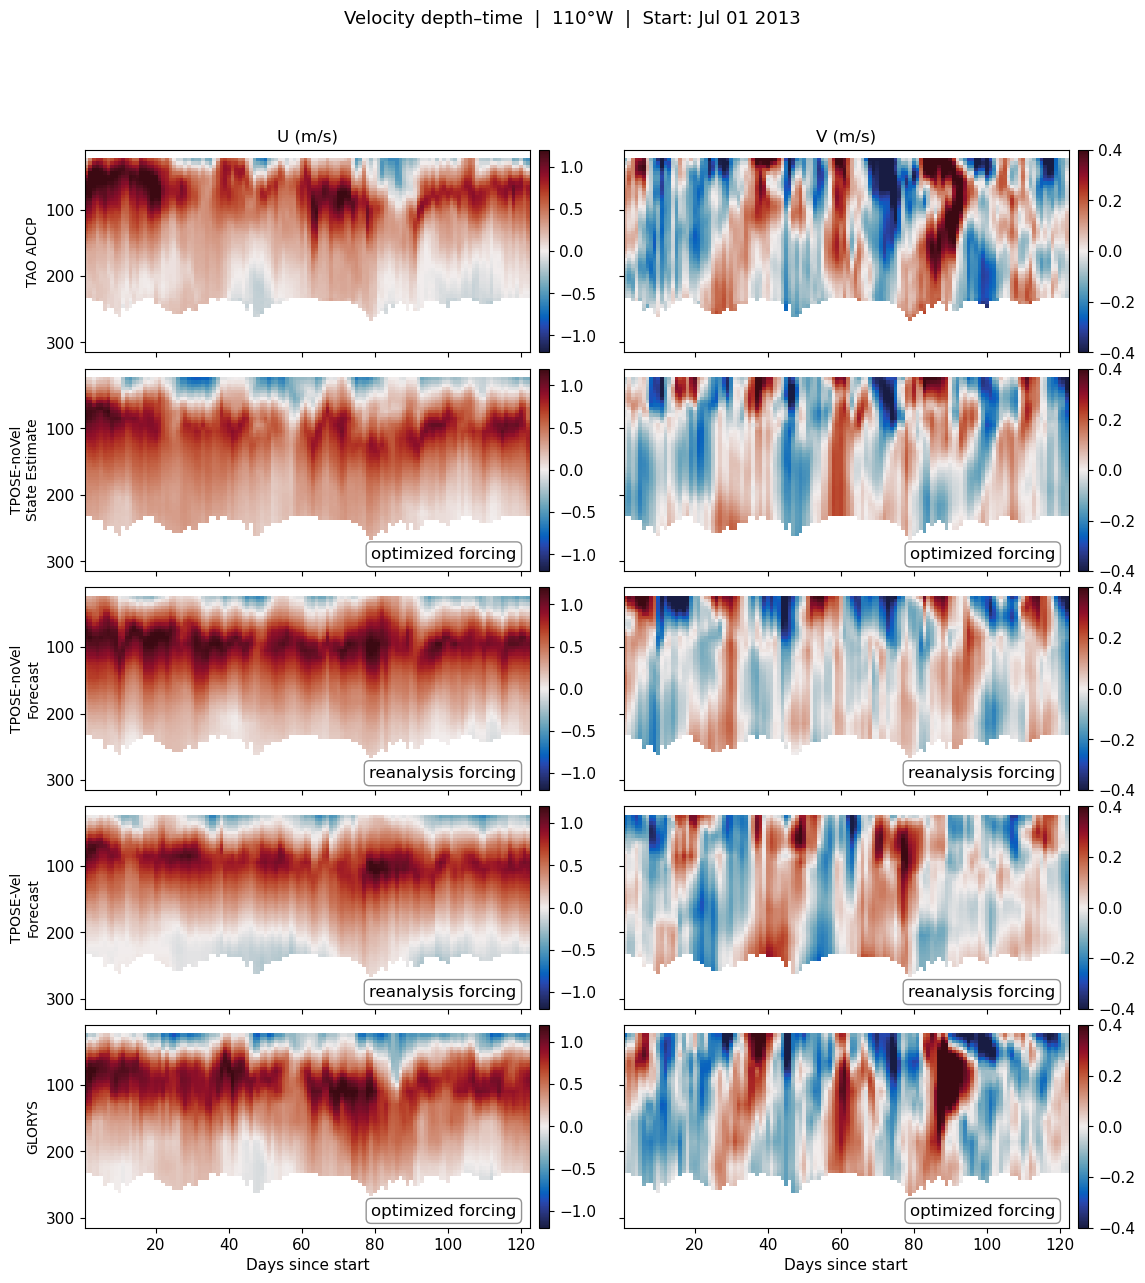

In [28]:
import cmocean.cm as cmo

row_labels = [
    'TAO ADCP',
    'TPOSE-noVel\nState Estimate',
    'TPOSE-noVel\nForecast',
    'TPOSE-Vel\nForecast',
    'GLORYS',
]

# Forcing-type label for each row (None = no bubble)
forcing_labels = [None, 'optimized forcing', 'reanalysis forcing', 'reanalysis forcing', 'optimized forcing']

datasets = [
    (tao_u,       tao_v),
    (noTAO_u,     noTAO_v),
    (noTAO_fct_u, noTAO_fct_v),
    (vel_fct_u,   vel_fct_v),
    (glorys_u,    glorys_v),
]

vlim_u = 1.2   # m/s
vlim_v = 0.4   # m/s

days   = np.arange(1, n_eval + 1)
depths = interp_depths   # positive downward (m)

for loc_idx, (lon_e, lon_label) in enumerate(zip(tao_lons, tao_lon_labels)):

    obs_mask_u = ~np.isfinite(tao_u[:, loc_idx, :])
    obs_mask_v = ~np.isfinite(tao_v[:, loc_idx, :])

    fig, axes = plt.subplots(
        5, 2, figsize=(13, 14),
        sharex=True, sharey=True,
        gridspec_kw={'hspace': 0.08, 'wspace': 0.15}
    )

    for row, ((u_arr, v_arr), row_label, forcing) in enumerate(zip(datasets, row_labels, forcing_labels)):
        u2d = u_arr[:, loc_idx, :].copy()
        v2d = v_arr[:, loc_idx, :].copy()
        u2d[obs_mask_u] = np.nan
        v2d[obs_mask_v] = np.nan

        for col, (data2d, vlim, comp_label) in enumerate([
            (u2d.T, vlim_u, 'U (m/s)'),
            (v2d.T, vlim_v, 'V (m/s)'),
        ]):
            ax = axes[row, col]
            pcm = ax.pcolormesh(
                days, depths, np.ma.masked_invalid(data2d),
                cmap=cmo.balance, vmin=-vlim, vmax=vlim,
                shading='auto'
            )
            fig.colorbar(pcm, ax=ax, fraction=0.03, pad=0.02)

            if col == 0:
                ax.set_ylabel(row_label, fontsize=10)
            if row == 0:
                ax.set_title(comp_label, fontsize=12)

            if forcing is not None:
                ax.text(0.97, 0.12, forcing, transform=ax.transAxes,
                        ha='right', va='top', fontsize=12,
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                                  edgecolor='gray', alpha=0.85))

    axes[0, 0].set_ylim(depths[-1], depths[0])

    for col in range(2):
        axes[-1, col].set_xlabel('Days since start')

    fig.suptitle(
        f'Velocity depth–time  |  {lon_label}  |  Start: {start_date.strftime("%b %d %Y")}',
        fontsize=13
    )
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(
        foldername + f'vel_hovmoller_{int(lon_e):03d}E_{month_str}{day_str}{year_str}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()

### Figures: depth–time Hovmöller of model minus TAO observations

Same layout but each panel shows (model − TAO obs). Row 1 is the obs itself (for reference);
rows 2–5 show the bias of each model product relative to the observations.

/tmp/ipykernel_28073/2595162702.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


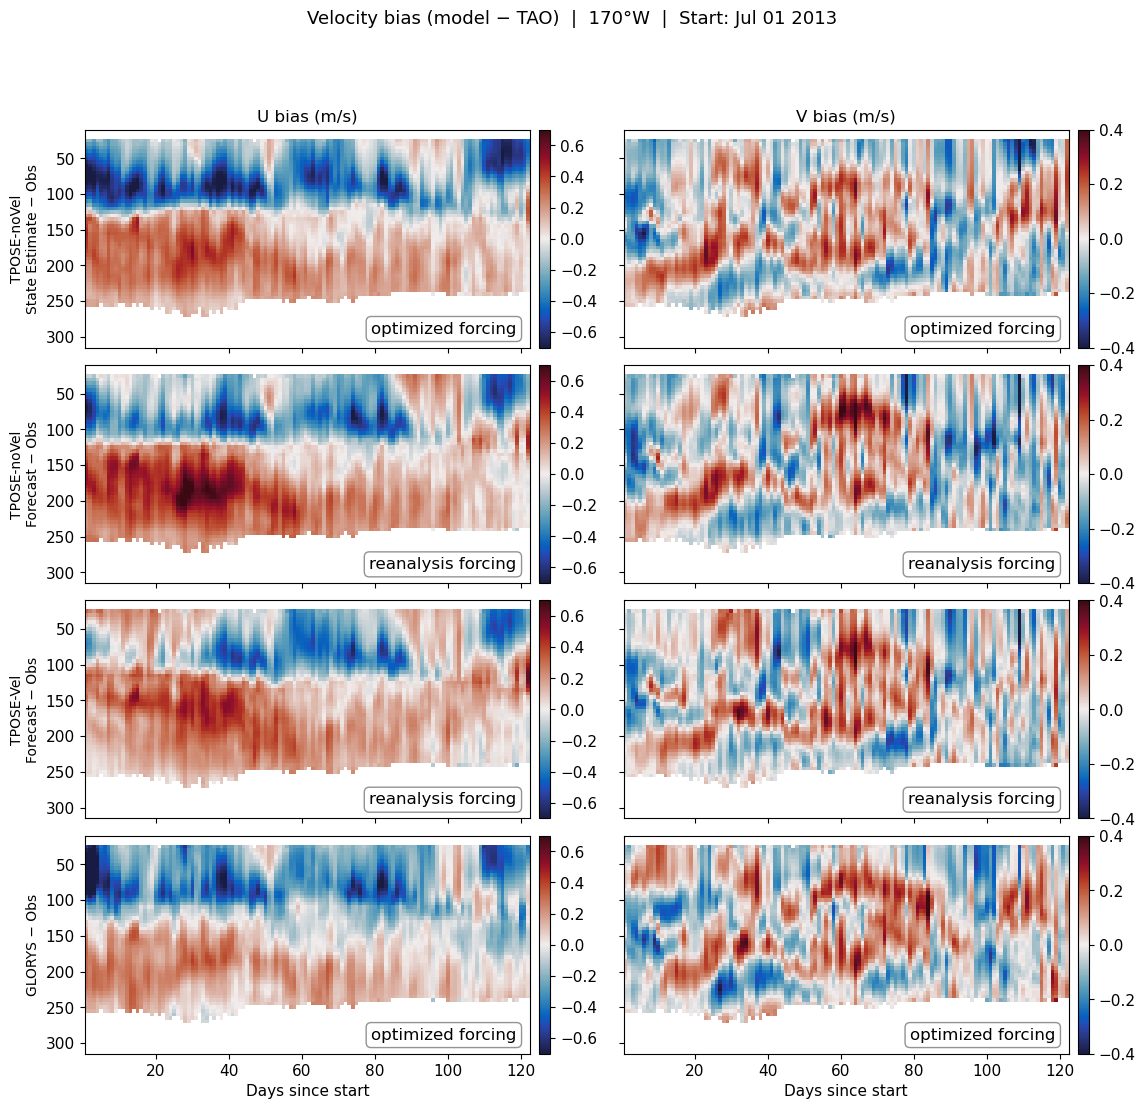

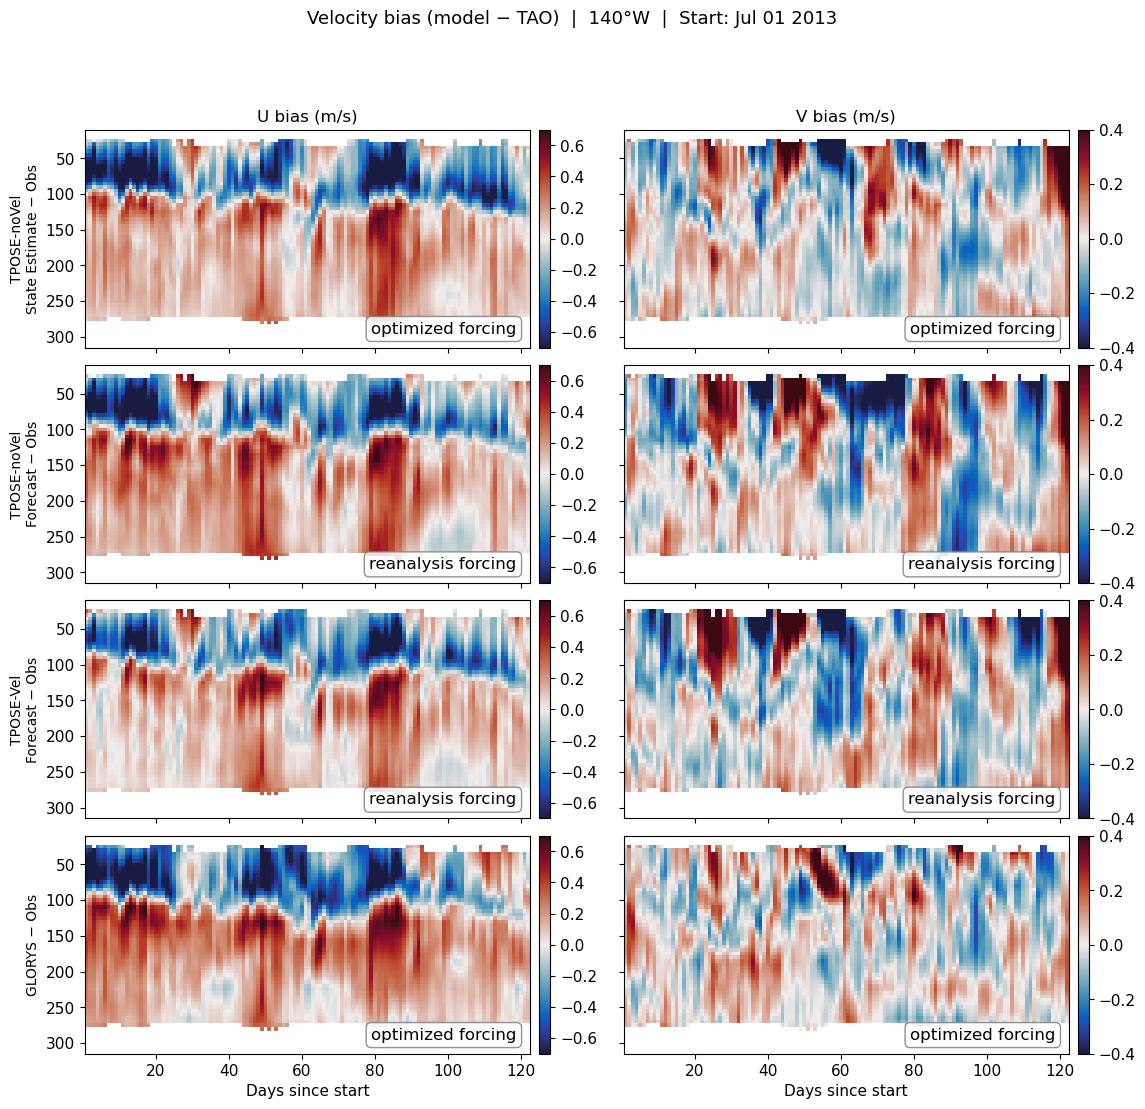

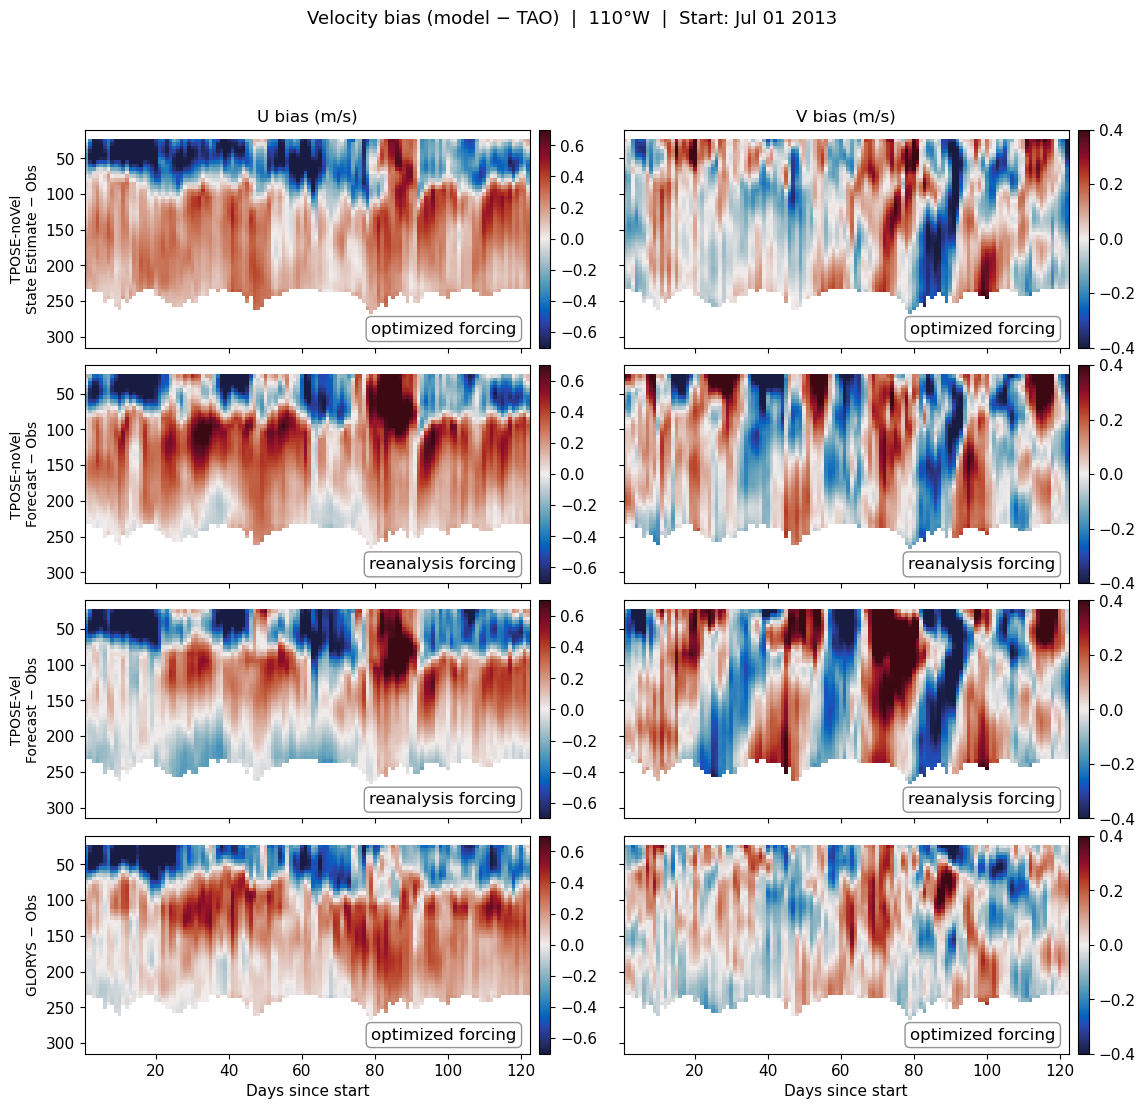

In [29]:
import cmocean.cm as cmo

diff_row_labels = [
    'TPOSE-noVel\nState Estimate − Obs',
    'TPOSE-noVel\nForecast − Obs',
    'TPOSE-Vel\nForecast − Obs',
    'GLORYS − Obs',
]

diff_forcing_labels = ['optimized forcing', 'reanalysis forcing', 'reanalysis forcing', 'optimized forcing']

model_datasets = [
    (noTAO_u,     noTAO_v),
    (noTAO_fct_u, noTAO_fct_v),
    (vel_fct_u,   vel_fct_v),
    (glorys_u,    glorys_v),
]

vlim_diff_u = 0.7   # m/s
vlim_diff_v = 0.4   # m/s

days   = np.arange(1, n_eval + 1)
depths = interp_depths

for loc_idx, (lon_e, lon_label) in enumerate(zip(tao_lons, tao_lon_labels)):

    obs_mask_u = ~np.isfinite(tao_u[:, loc_idx, :])
    obs_mask_v = ~np.isfinite(tao_v[:, loc_idx, :])

    obs_u = tao_u[:, loc_idx, :].copy()
    obs_v = tao_v[:, loc_idx, :].copy()

    fig, axes = plt.subplots(
        4, 2, figsize=(13, 12),
        sharex=True, sharey=True,
        gridspec_kw={'hspace': 0.08, 'wspace': 0.15}
    )

    for row, ((u_arr, v_arr), row_label, forcing) in enumerate(
            zip(model_datasets, diff_row_labels, diff_forcing_labels)):
        diff_u = u_arr[:, loc_idx, :] - obs_u
        diff_v = v_arr[:, loc_idx, :] - obs_v
        diff_u[obs_mask_u] = np.nan
        diff_v[obs_mask_v] = np.nan

        for col, (data2d, vlim, comp_label) in enumerate([
            (diff_u.T, vlim_diff_u, 'U bias (m/s)'),
            (diff_v.T, vlim_diff_v, 'V bias (m/s)'),
        ]):
            ax = axes[row, col]
            pcm = ax.pcolormesh(
                days, depths, np.ma.masked_invalid(data2d),
                cmap=cmo.balance, vmin=-vlim, vmax=vlim,
                shading='auto'
            )
            fig.colorbar(pcm, ax=ax, fraction=0.03, pad=0.02)

            if col == 0:
                ax.set_ylabel(row_label, fontsize=10)
            if row == 0:
                ax.set_title(comp_label, fontsize=12)

            ax.text(0.97, 0.12, forcing, transform=ax.transAxes,
                    ha='right', va='top', fontsize=12,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              edgecolor='gray', alpha=0.85))

    axes[0, 0].set_ylim(depths[-1], depths[0])

    for col in range(2):
        axes[-1, col].set_xlabel('Days since start')

    fig.suptitle(
        f'Velocity bias (model − TAO)  |  {lon_label}  |  Start: {start_date.strftime("%b %d %Y")}',
        fontsize=13
    )
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(
        foldername + f'vel_hovmoller_bias_{int(lon_e):03d}E_{month_str}{day_str}{year_str}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()